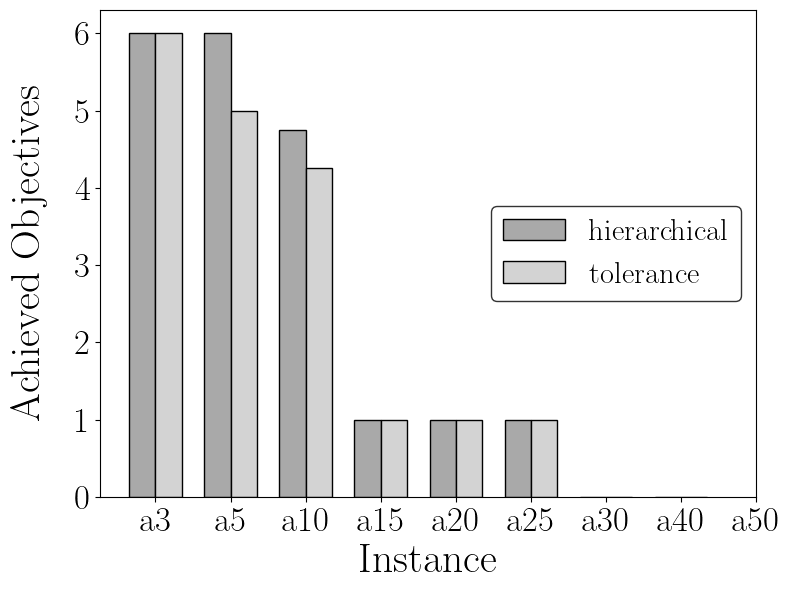

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Load CSV file
data = pd.read_csv("filtered_data.csv")

# Relevant columns and methods
objectives = ["Construction Fulfillment", "Driver Violation", "Commute Distance", "Transport Distance", "Machine Count", "Worker Count"]
methods_to_analyze = ["hierarchical", "tolerance"]

# Filter data for the selected methods
filtered_data = data[data["Method"].isin(methods_to_analyze)].copy()

# Function to calculate achieved objectives
def count_achieved_objectives(row):
    count = 0
    for obj in objectives:
        if pd.notna(row[obj]) and "*" not in str(row[obj]) and row[obj] != "-":
            count += 1
        else:
            break  # From this point, the objective was not achieved
    return count

# Add a column for achieved objectives
filtered_data["Achieved Objectives"] = filtered_data.apply(count_achieved_objectives, axis=1)

# Simplify instance names (e.g., a10_o107 -> a10)
filtered_data["Instance"] = filtered_data["Instance"].str.extract(r"(a\d+)")

# Aggregate "a10" instances
a10_data = filtered_data[filtered_data["Instance"] == "a10"]
a10_avg = a10_data.groupby("Method")["Achieved Objectives"].mean().reset_index()
a10_avg["Instance"] = "a10"

# Keep other instances
non_a10_data = filtered_data[filtered_data["Instance"] != "a10"]

# Combine aggregated data
combined_data = pd.concat([non_a10_data, a10_avg], ignore_index=True)

# Sort instances (a3 to a50)
combined_data["Instance"] = pd.Categorical(
    combined_data["Instance"], 
    categories=sorted(combined_data["Instance"].unique(), key=lambda x: int(x[1:])),
    ordered=True
)

# Group by instance and method
grouped = combined_data.groupby(["Instance", "Method"], observed=True)["Achieved Objectives"].max().unstack()

# Mark instances where "Construction Fulfillment" is "-"
instances_to_hide = filtered_data.loc[filtered_data["Construction Fulfillment"] == "-", "Instance"].unique()

# Grouped bar plot
x = np.arange(len(grouped.index))  # Positions for instances
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["darkgray", "lightgray"]  # Two shades of gray for the methods
for method, color in zip(methods_to_analyze, colors):
    # Hide bars for instances with "-"
    y_values = grouped[method].where(~grouped.index.isin(instances_to_hide))
    ax.bar(
        x - width/2 if method == "hierarchical" else x + width/2, 
        y_values, 
        width, 
        label=method, 
        color=color, 
        edgecolor="black"
    )

# Update plot styling
rcParams.update({
    "text.usetex": True,  # LaTeX-style text
    "font.family": "serif",  # Serif font
    "axes.labelsize": 35,  # Axis label size
    "xtick.labelsize": 25,  # X-tick size
    "ytick.labelsize": 25,  # Y-tick size
})

# Diagram details in English
ax.set_xlabel("Instance")
ax.set_ylabel("Achieved Objectives", labelpad=20)
#ax.set_title("Achieved Objectives per Instance")
ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=0)
ax.legend(edgecolor="black", loc="center right", frameon=True, fontsize=22)
plt.tight_layout()
plt.savefig("achieved_objectives_per_instance.pdf")
plt.show()